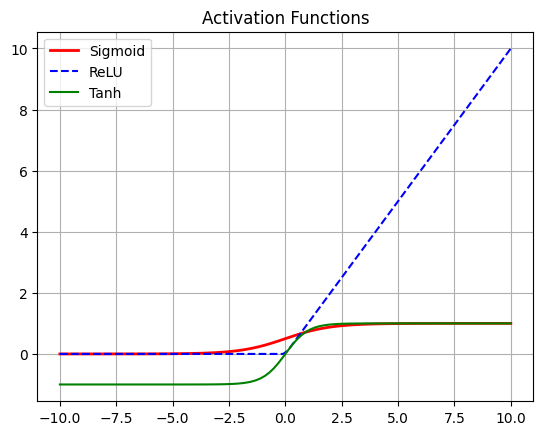

In [3]:
#Q15

import numpy as np
import matplotlib.pyplot as plt

# create values from -10 to 10
x = np.linspace(-10, 10, 100)

# activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

def tanh(x):
    return np.tanh(x)

# plot all functions with distinct colors
plt.plot(x, sigmoid(x), label="Sigmoid", color="red", linewidth=2)
plt.plot(x, relu(x), label="ReLU", color="blue", linestyle="--")
plt.plot(x, tanh(x), label="Tanh", color="green")

plt.title("Activation Functions")
plt.legend()
plt.grid()

plt.show()

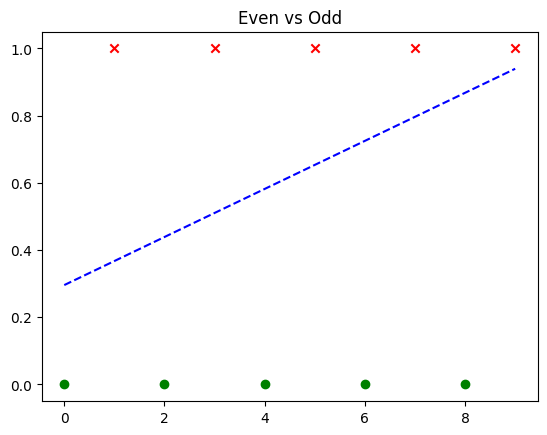

In [4]:
# Q2

import numpy as np
import matplotlib.pyplot as plt

# Data
X = np.array([[i, i % 2] for i in range(10)])
y = np.array([i % 2 for i in range(10)])  # 0=even, 1=odd

# Initialize
w = np.random.rand(2)
b = np.random.rand()
lr = 0.1

# Train perceptron
for _ in range(30):
    for xi, target in zip(X, y):
        pred = 1 if np.dot(w, xi) + b >= 0 else 0
        w += lr * (target - pred) * xi
        b += lr * (target - pred)

# Plot
for xi, label in zip(X, y):
    plt.scatter(xi[0], xi[1], c='red' if label else 'green', marker='x' if label else 'o')

x = np.linspace(0, 9, 100)
plt.plot(x, -(w[0]*x + b)/w[1], 'b--')

plt.title("Even vs Odd")
plt.show()

In [5]:
# Q3

# McCulloch-Pitts neuron for ANDNOT function

def andnot(x1, x2):
    # weights
    w1 = 1
    w2 = -1
    
    # threshold
    theta = 1
    
    # weighted sum
    net_input = x1 * w1 + x2 * w2
    
    # activation function (step function)
    if net_input >= theta:
        return 1
    else:
        return 0


# Test all input combinations
inputs = [(0,0), (0,1), (1,0), (1,1)]

print("x1 x2 -> Output")
for x1, x2 in inputs:
    output = andnot(x1, x2)
    print(x1, x2, "->", output)

x1 x2 -> Output
0 0 -> 0
0 1 -> 0
1 0 -> 1
1 1 -> 0


In [7]:


#Q4
import numpy as np

# XOR Data
X, y = np.array([[0, 0], [0, 1], [1, 0], [1, 1]]), np.array([[0], [1], [1], [0]])

# Initialize weights and bias
np.random.seed(1)
W1, W2 = np.random.rand(2, 2), np.random.rand(2, 1)
b1, b2 = np.zeros((1, 2)), np.zeros((1, 1))

# Sigmoid function and derivative
sigmoid = lambda x: 1 / (1 + np.exp(-x))
sigmoid_d = lambda x: x * (1 - x)

# Training
for _ in range(10000):
    h = sigmoid(np.dot(X, W1) + b1)
    out = sigmoid(np.dot(h, W2) + b2)
    error = y - out
    W2 += h.T.dot(error * sigmoid_d(out)) * 0.1
    W1 += X.T.dot((error * sigmoid_d(out)).dot(W2.T) * sigmoid_d(h)) * 0.1
    b2 += np.sum(error * sigmoid_d(out), axis=0) * 0.1
    b1 += np.sum((error * sigmoid_d(out)).dot(W2.T) * sigmoid_d(h), axis=0) * 0.1

# Output
print("Output after training:", out)

Output after training: [[0.06622852]
 [0.93824699]
 [0.93838596]
 [0.0670079 ]]


In [8]:
# Q5

import pandas as pd
from keras.models import Sequential
from keras.layers import Dense
from keras.utils import to_categorical

data = pd.read_csv("Iris [FNN].csv")
X = data.iloc[:, 1:-1].values
Y = to_categorical(pd.factorize(data.iloc[:, -1])[0])

model = Sequential([
    Dense(10, activation='relu', input_shape=(4,)),
    Dense(3, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy')
model.fit(X, Y, epochs=10, verbose=0)

print(model.predict(X)[:5])


C:\Users\Janhvi Indapurkar\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
[[0.5090436  0.24785462 0.24310178]
 [0.47803533 0.2516642  0.27030054]
 [0.48974654 0.25623688 0.2540165 ]
 [0.49033317 0.25527772 0.25438914]
 [0.516285   0.2491395  0.2345755 ]]


In [9]:
# Q5 AND Q8

import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

d = pd.read_csv("IMDB Dataset [RNN].csv")
t = Tokenizer(5000)
t.fit_on_texts(d['review'])
X = pad_sequences(t.texts_to_sequences(d['review']), maxlen=100)
y = pd.factorize(d['sentiment'])[0]

m = Sequential([Embedding(5000,32), SimpleRNN(10), Dense(1,'sigmoid')])
m.compile('adam','binary_crossentropy')
m.fit(X,y,epochs=3)

print((m.predict(X[:5]) > 0.5).astype(int))

Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 48s 29ms/step - loss: 0.4567
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - loss: 0.3627
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 46s 29ms/step - loss: 0.3162
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step
[[0]
 [0]
 [0]
 [1]
 [0]]


In [10]:
#Q6

import tensorflow as tf

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize and reshape
x_train = x_train.reshape(-1,28,28,1)/255.0
x_test  = x_test.reshape(-1,28,28,1)/255.0

# Build CNN
model = tf.keras.Sequential([
  tf.keras.layers.Conv2D(16,3,activation='relu',input_shape=(28,28,1)),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(10,'softmax')
])

# Compile + Train
model.compile('adam','sparse_categorical_crossentropy',metrics=['accuracy'])
model.fit(x_train,y_train,epochs=5)

# Evaluate
print("Test accuracy:", model.evaluate(x_test,y_test)[1])


C:\Users\Janhvi Indapurkar\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.9199 - loss: 0.2835
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9698 - loss: 0.1074
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9785 - loss: 0.0746
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9823 - loss: 0.0603
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9847 - loss: 0.0528
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9793 - loss: 0.0614
Test accuracy: 0.9793000221252441


In [11]:
#Q7

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense
from tensorflow.keras.utils import to_categorical

# Load + prep data
(x_train,y_train),(x_test,y_test)=mnist.load_data()
x_train=x_train.reshape(-1,28,28,1)/255.0; x_test=x_test.reshape(-1,28,28,1)/255.0
y_train,y_test=to_categorical(y_train),to_categorical(y_test)

# CNN model
model=Sequential([Conv2D(16,3,activation='relu',input_shape=(28,28,1)),
                  MaxPooling2D(),Flatten(),Dense(10,'softmax')])

# Train + evaluate
model.compile('adam','categorical_crossentropy',metrics=['accuracy'])
model.fit(x_train,y_train,epochs=1,verbose=0)
print(model.evaluate(x_test,y_test))


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9640 - loss: 0.1227
[0.12266255170106888, 0.9639999866485596]


In [13]:
#Q9

import pandas as pd, numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

d = pd.read_csv("weatherHistory.csv")
X = np.array(d['Temperature (C)'][:-1]).reshape(-1,1,1)
y = np.array(d['Temperature (C)'][1:])

m = Sequential([LSTM(10,input_shape=(1,1)), Dense(1)])
m.compile('adam','mse')
m.fit(X,y,epochs=5,verbose=0)
print("Loss, MAE:", m.evaluate(X,y,verbose=0))
print("Pred:", m.predict(X[:5]).flatten())

C:\Users\Janhvi Indapurkar\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Loss, MAE: 2.472414016723633
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step
Pred: [9.430026 9.312559 9.334922 8.245224 8.710771]


Reconstruction Error: 0.0098


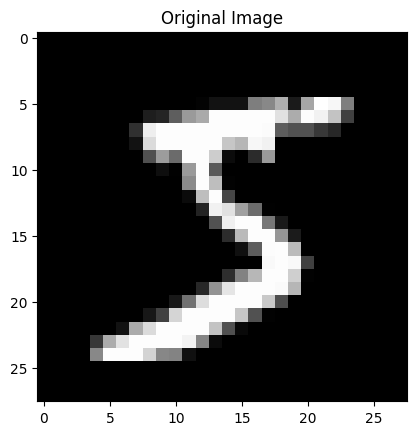

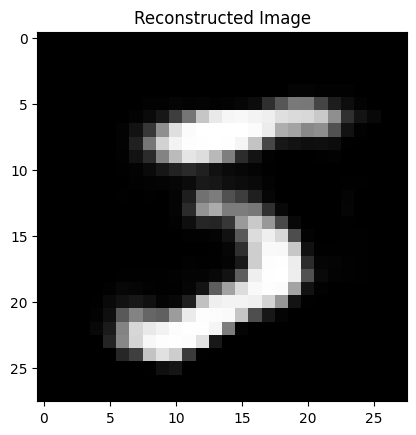

In [17]:


# Q.10) 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


data = pd.read_csv("mnist_train.csv")
X = data.drop('label', axis=1).values / 255.0


model = Sequential()
model.add(Dense(32, activation='relu'))
model.add(Dense(784, activation='sigmoid'))
model.compile(optimizer='adam', loss='mse')

model.fit(X, X, epochs=5, verbose=0)
recon = model.predict(X[:100], verbose=0)

error = np.mean((X[:100] - recon) ** 2)
print("Reconstruction Error:", round(error,4))

plt.imshow(X[0].reshape(28,28), cmap='gray')
plt.title("Original Image")
plt.show()

plt.imshow(recon[0].reshape(28,28), cmap='gray')
plt.title("Reconstructed Image")
plt.show()

In [ ]:
# Q.11)
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

gen = models.Sequential([
    layers.Dense(64, activation='relu', input_dim=10),
    layers.Dense(20, activation='sigmoid')   
])

disc = models.Sequential([
    layers.Dense(64, activation='relu', input_dim=20),
    layers.Dense(1, activation='sigmoid')
])
disc.compile(optimizer='adam', loss='binary_crossentropy')
disc.trainable = False
gan = models.Sequential([gen, disc])
gan.compile(optimizer='adam', loss='binary_crossentropy')

for i in range(200):
    real = np.random.rand(16, 20)
    noise = np.random.rand(16, 10)
    fake = gen.predict(noise, verbose=0)
    X = np.vstack([real, fake])
    y = np.vstack([np.ones((16,1)), np.zeros((16,1))])
    disc.trainable = True
    disc.train_on_batch(X, y)
    disc.trainable = False
    gan.train_on_batch(noise, np.ones((16,1)))

sample = gen.predict(np.random.rand(1,10))

plt.imshow(sample.reshape(4,5), cmap='gray')
plt.title("Generated Image")
plt.axis('off')
plt.show()